# multi-salary dataset - but this process is valid



## Loading Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../datasets/SalaryMulti.csv")
df.head()



,Total Experience,Team Lead Experience,Project Manager Experience,Certifications,Salary
0,7,2,4,1,77318.070547
1,4,0,2,3,64951.950980
2,13,4,8,3,106058.185204
3,11,3,2,1,89649.944851
4,8,1,6,3,82206.019687


## Data cleaning

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Total Experience            1000 non-null   int64  
 1   Team Lead Experience        1000 non-null   int64  
 2   Project Manager Experience  1000 non-null   int64  
 3   Certifications              1000 non-null   int64  
 4   Salary                      1000 non-null   float64
dtypes: float64(1), int64(4)
memory usage: 39.2 KB


In [4]:
df.shape

(1000, 5)

In [5]:
df.isnull().count()

Total Experience              1000
Team Lead Experience          1000
Project Manager Experience    1000
Certifications                1000
Salary                        1000
dtype: int64

In [6]:
df.drop_duplicates()

,Total Experience,Team Lead Experience,Project Manager Experience,Certifications,Salary
0,7,2,4,1,77318.070547
1,4,0,2,3,64951.950980
2,13,4,8,3,106058.185204
3,11,3,2,1,89649.944851
4,8,1,6,3,82206.019687
...,...,...,...,...,...
995,8,1,6,4,90941.688891
996,12,3,1,2,92074.890941
997,14,10,1,2,115914.944924
998,7,5,0,2,82706.285700


In [7]:
df.dtypes

Total Experience                int64
Team Lead Experience            int64
Project Manager Experience      int64
Certifications                  int64
Salary                        float64
dtype: object

**Conclusion:** Data is already clean

## Check for the type of data - linear or not


In [8]:
df.corr()*100

,Total Experience,Team Lead Experience,Project Manager Experience,Certifications,Salary
Total Experience,100.000000,65.285648,47.766245,-1.926535,94.184922
Team Lead Experience,65.285648,100.000000,-10.065885,-2.922642,75.377169
Project Manager Experience,47.766245,-10.065885,100.000000,1.544062,40.578571
Certifications,-1.926535,-2.922642,1.544062,100.000000,0.967840
Salary,94.184922,75.377169,40.578571,0.967840,100.000000


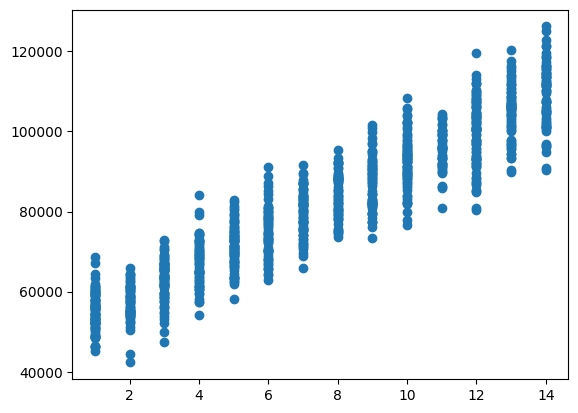

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df['Total Experience'] , df['Salary'],)
plt.show()

## Data Preparation - separating train and test data 

### Separating data into X and y

In [10]:
X = df[['Total Experience', 'Team Lead Experience', 'Project Manager Experience', 'Certifications' ]]
                # OR
# X = df.drop('Salary', axis = 1)   
X    #2d

,Total Experience,Team Lead Experience,Project Manager Experience,Certifications
0,7,2,4,1
1,4,0,2,3
2,13,4,8,3
3,11,3,2,1
4,8,1,6,3
...,...,...,...,...
995,8,1,6,4
996,12,3,1,2
997,14,10,1,2
998,7,5,0,2


In [11]:
y = df['Salary']  #1d
y

0       77318.070547
1       64951.950980
2      106058.185204
3       89649.944851
4       82206.019687
           ...      
995     90941.688891
996     92074.890941
997    115914.944924
998     82706.285700
999     85347.167601
Name: Salary, Length: 1000, dtype: float64

### Separating X and y into Training and test data

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### model training - separation of training and test data

In [13]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()  # object of class LinearRegression

model_lr.fit(X_train,y_train)  # but actually we should have given training data (xtrain, ytrain)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
slope = model_lr.coef_
print(slope)
df.dtypes

[2988.17486511 1898.17107701  974.70334101  371.32169738]


Total Experience                int64
Team Lead Experience            int64
Project Manager Experience      int64
Certifications                  int64
Salary                        float64
dtype: object

In [15]:
intercept = model_lr.intercept_
intercept

np.float64(50769.34540329706)

**Conclusion:** 
1. **_Slope:_**  - Each feature column has separate slope values
- When **"Total Experience"** increases by 1 unit **"salary"** increases by 2989.147
- When **"Team Lead Experience"** increases by 1 unit **"salary"** increases by 1911.848
- When **"Project Manager Experience"** increases by 1 unit **"salary"**increases by 989.716
- When **"Certifictaions** increases by 1 unit **"salary"** increases by 389.886
> finally we can say that : **"Salary"**  is strongly correlated/ depends  to/on  **"Total Experience"** 

2. **_Intercept:_**
- The initial or starting **Salary** for a **fresher** with **zero experience** is **_50634.143_**

### model prediction and evaluation

#### train data

In [16]:
y_pred_train = model_lr.predict(X_train)
y_pred_train

array([ 54871.48536056,  74674.74432419,  83176.60807911,  89075.90695544,
        94333.57459495,  94964.23053953,  71043.08427743,  53757.52026841,
        88871.12131015, 102350.67015023,  86638.57585162, 105850.88751594,
        70991.84867242,  79303.21507119,  57859.66022567,  53757.52026841,
       104106.2664792 , 100017.11253375,  98296.45280107, 104736.92242378,
        63901.53385004,  69325.73754165, 104708.3458455 ,  93962.25289757,
       108235.68073742, 106119.89477805, 105441.31622536,  82741.22153965,
        54500.16366318,  63901.53385004,  65015.49894219,  54128.84196579,
        66156.7383353 , 109841.04002301, 113507.63666607,  88717.57126987,
        83650.40098651,  54871.48536056,  93603.917212  ,  54500.16366318,
        91654.51052997,  93667.98205407, 103400.5704003 , 108350.9811845 ,
        65042.77324315,  84588.15701165,  54500.16366318,  53757.52026841,
        73980.02353753,  64439.39159952,  57859.66022567,  64810.7132969 ,
        91270.35959552,  

In [17]:
# if error is less model is performing good

#### importing and evaluating the model using metrics

In [18]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [19]:
# r2_score(X_train, y_train) 
# This gives an error because r2_score expects actual y and predicted y, not X_train and y_train.”
r2_score(y_train, y_pred_train)

0.9246234355892218

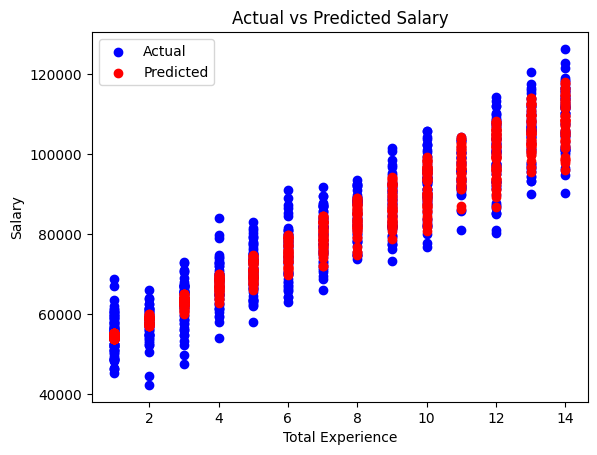

In [22]:
import matplotlib.pyplot as plt

plt.scatter(X_train['Total Experience'], y_train, color='blue', label='Actual')
plt.scatter(X_train['Total Experience'], y_pred_train, color='red', label='Predicted')
plt.xlabel('Total Experience')
plt.ylabel('Salary')
plt.title('Actual vs Predicted Salary')
plt.legend()
plt.show()

#### test data

In [25]:
y_pred_test = model_lr.predict(X_test)
y_pred_test

array([109210.38407843,  76699.34791527,  72198.61195967,  98477.27714231,
       100823.8207706 ,  53757.52026841,  62978.06611404,  68634.32975189,
        90062.13725619,  71595.23031604, 118765.30430558, 108211.71943336,
        95334.09318484,  74416.86912906, 110764.50775902,  84458.56827543,
        82267.42863225,  65015.49894219,  58463.0418693 ,  91743.99572818,
        54871.48536056, 100156.37428489,  65015.49894219,  64207.33165328,
       100593.21987643,  63349.38781142, 104824.94856991,  60129.15300007,
        54871.48536056,  55242.80705794,  82457.92598839,  95154.72789568,
        61683.27668065,  75790.16846841,  76852.89795555, 106699.15834288,
        73674.2257343 ,  95116.47830248,  78189.24997904,  93219.6095028 ,
        84625.10432752,  66518.38701777,  79098.4294259 ,  74045.54743168,
       103632.63034655,  69159.20148955,  71827.29026229,  67683.58771493,
        77942.90174365,  57859.66022567,  63530.21215266,  91960.3083332 ,
        58091.72017191,  

In [26]:
error = y_test - y_pred_test
error

521   -3797.898184
737   -2596.812752
740     787.849368
660    9877.548735
411    1427.180261
          ...     
408    4759.574425
332   -3606.525417
208    2504.485213
613   -4384.883953
78     2526.839291
Name: Salary, Length: 200, dtype: float64

mams

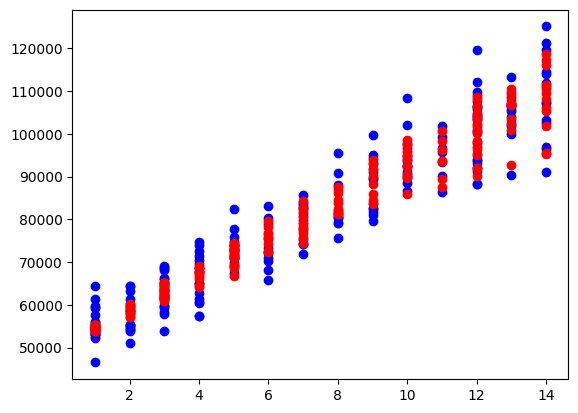

In [27]:
import matplotlib.pyplot as plt 

plt.scatter(X_test['Total Experience'], y_test , color="b")
plt.scatter(X_test['Total Experience'], y_pred_test, color='red')


#### checking the overfitting/ underfit/ goodfit

In [28]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [29]:
train_r2 = r2_score(y_train, y_pred_train)

test_r2 = r2_score(y_test, y_pred_test)

print("Train R2 :", train_r2)
print("Test R2  :", test_r2)

Train R2 : 0.9246234355892218
Test R2  : 0.940614842359922


**conclusion: (overfitting / underfitting/ goodfit)**
- train data r2_score = 0.9246 --> 92.4
- test data r2_score = 0.9406 --> 94.06
- since model is performing well on both the data(train and test) - model is **goodfit**
